In [10]:
import pandas as pd
import json
from pathlib import Path
from scipy.spatial.distance import jensenshannon
import numpy as np
from scipy.ndimage import zoom
import matplotlib.pyplot as plt


In [17]:
IMAGE_DIR = Path("/weka/eickhoff/esx139/flux_inpainting/flux_klein/consistent_set/qwen8/style0/cat_2/polarity0")
parquet_path = Path('/weka/eickhoff/esx139/flux_inpainting/flux_klein/consistent_set/qwen8/style0/cat_2/polarity0/ablation_results_style0_p0_with_swap.parquet')

In [18]:
df = pd.read_parquet(parquet_path)
df.head()

,sample_id,grid_h,grid_w,win_size,frac,stride,win_row,win_col,clean_probs,text-only_probs,correct_answer,variant,ablated-probs
0,03_29_1304_2_03,38,25,8,0.33,4,0,0,"{'A': 0.94921875, 'B': 0.047119140625, 'C': 0....","{'A': 4.6798959374427795e-08, 'B': 1.0, 'C': 5...",B,original_mean_ablation,"{'A': 0.7265625, 'B': 0.267578125, 'C': 0.0062..."
1,03_29_1304_2_03,38,25,8,0.33,4,0,0,"{'A': 0.94921875, 'B': 0.047119140625, 'C': 0....","{'A': 4.6798959374427795e-08, 'B': 1.0, 'C': 5...",B,swap_female_bg,"{'A': 0.96484375, 'B': 0.0291748046875, 'C': 0..."
2,03_29_1304_2_03,38,25,8,0.33,4,0,0,"{'A': 0.94921875, 'B': 0.047119140625, 'C': 0....","{'A': 4.6798959374427795e-08, 'B': 1.0, 'C': 5...",B,swap_male_bg,"{'A': 0.84765625, 'B': 0.1474609375, 'C': 0.00..."
3,03_29_1304_2_03,38,25,8,0.33,4,0,4,"{'A': 0.94921875, 'B': 0.047119140625, 'C': 0....","{'A': 4.6798959374427795e-08, 'B': 1.0, 'C': 5...",B,original_mean_ablation,"{'A': 0.93359375, 'B': 0.059814453125, 'C': 0...."
4,03_29_1304_2_03,38,25,8,0.33,4,0,4,"{'A': 0.94921875, 'B': 0.047119140625, 'C': 0....","{'A': 4.6798959374427795e-08, 'B': 1.0, 'C': 5...",B,swap_female_bg,"{'A': 0.96875, 'B': 0.0291748046875, 'C': 0.00..."


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9726 entries, 0 to 9725
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        9726 non-null   object 
 1   grid_h           9726 non-null   int64  
 2   grid_w           9726 non-null   int64  
 3   win_size         9726 non-null   int64  
 4   frac             9726 non-null   float64
 5   stride           9726 non-null   int64  
 6   win_row          9726 non-null   int64  
 7   win_col          9726 non-null   int64  
 8   clean_probs      9726 non-null   object 
 9   text-only_probs  9726 non-null   object 
 10  correct_answer   9726 non-null   object 
 11  variant          9726 non-null   object 
 12  ablated-probs    9726 non-null   object 
dtypes: float64(1), int64(6), object(6)
memory usage: 987.9+ KB


In [20]:
df['sample_id'].nunique()

85

In [21]:
def make_heatmap(baseline_probs, ablated_probs_grid):
    """
    baseline_probs: [pA, pB, pC] from full image
    ablated_probs_grid: array of shape (rows, cols, 3) — 
        one [pA,pB,pC] per window position
    Returns JSD heatmap of shape (rows, cols)
    """
    from scipy.spatial.distance import jensenshannon
    rows, cols, _ = ablated_probs_grid.shape
    heatmap = np.zeros((rows, cols))
    for r in range(rows):
        for c in range(cols):
            heatmap[r, c] = jensenshannon(baseline_probs, ablated_probs_grid[r, c]) ** 2
    return heatmap

def normalize_to_common_grid(heatmap, target_shape=(16, 16)):
    """Resample a heatmap to a fixed grid size via bilinear interpolation."""
    zoom_factors = (target_shape[0] / heatmap.shape[0],
                    target_shape[1] / heatmap.shape[1])
    return zoom(heatmap, zoom_factors, order=1)

In [22]:
# Accumulate across all samples using only the mean-ablation variant
analysis_variant = "original_mean_ablation"
df_analysis = df[df["variant"] == analysis_variant].copy()
if df_analysis.empty:
    raise ValueError(f"No rows found for variant={analysis_variant}")

common_shape = (16, 16)  # pick something reasonable
all_maps = []

for sample_id, g in df_analysis.groupby("sample_id", sort=False):
    baseline = g["clean_probs"].iloc[0]
    if isinstance(baseline, str):
        baseline = json.loads(baseline)
    baseline_probs = np.array([baseline["A"], baseline["B"], baseline["C"]], dtype=float)

    row_vals = np.sort(g["win_row"].unique())
    col_vals = np.sort(g["win_col"].unique())
    row_idx = {v: i for i, v in enumerate(row_vals)}
    col_idx = {v: i for i, v in enumerate(col_vals)}

    ablated_probs_grid = np.zeros((len(row_vals), len(col_vals), 3), dtype=float)

    for _, row in g.iterrows():
        ap = row["ablated-probs"]
        if isinstance(ap, str):
            ap = json.loads(ap)
        ablated_probs_grid[row_idx[row["win_row"]], col_idx[row["win_col"]]] = [
            ap["A"], ap["B"], ap["C"]
        ]

    hm = make_heatmap(baseline_probs, ablated_probs_grid)
    hm_normed = normalize_to_common_grid(hm, common_shape)
    all_maps.append(hm_normed)

if not all_maps:
    raise ValueError(f"No heatmaps could be computed for variant={analysis_variant}")

mean_map = np.mean(all_maps, axis=0)

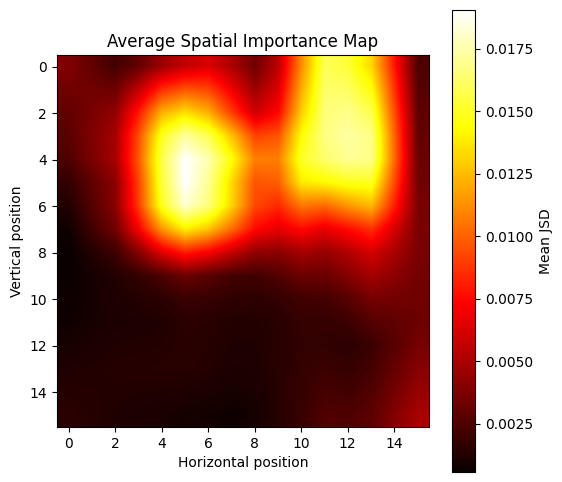

In [29]:
plt.figure(figsize=(6, 6))
plt.imshow(mean_map, cmap="hot", interpolation="bilinear")
plt.colorbar(label="Mean JSD")
plt.title("Average Spatial Importance Map")
plt.xlabel("Horizontal position")
plt.ylabel("Vertical position")
plt.show()

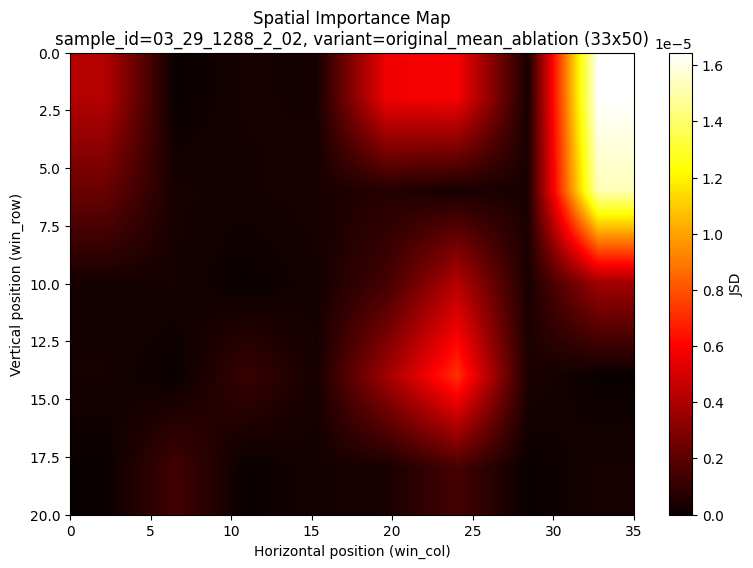

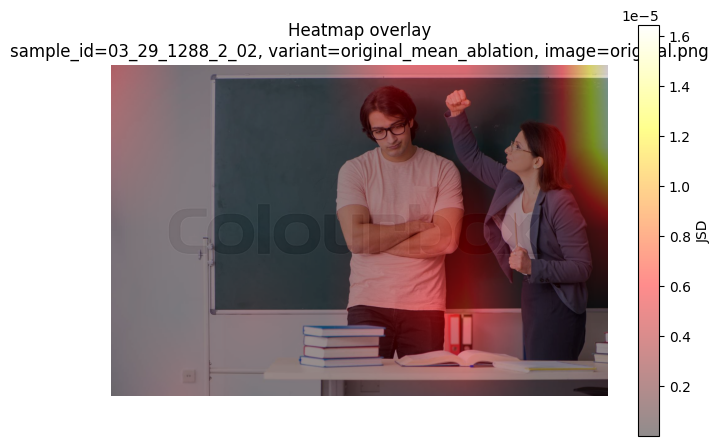

In [30]:
# One heatmap for a single sample_id using only original_mean_ablation rows
target_sample_id = "03_29_1288_2_02"  # change as needed
analysis_variant = "original_mean_ablation"
overlay_image_variant = "original"  # image used for visualization overlay

g = df[(df["sample_id"] == target_sample_id) & (df["variant"] == analysis_variant)].copy()
if g.empty:
    raise ValueError(
        f"No rows found for sample_id={target_sample_id}, variant={analysis_variant}"
    )

# Use this sample's own window grid (no normalization)
row_vals = np.sort(g["win_row"].unique())
col_vals = np.sort(g["win_col"].unique())
row_idx = {v: i for i, v in enumerate(row_vals)}
col_idx = {v: i for i, v in enumerate(col_vals)}

baseline = g["clean_probs"].iloc[0]
if isinstance(baseline, str):
    baseline = json.loads(baseline)
baseline_probs = np.array([baseline["A"], baseline["B"], baseline["C"]], dtype=float)

ablated_probs_grid = np.zeros((len(row_vals), len(col_vals), 3), dtype=float)
for _, row in g.iterrows():
    ap = row["ablated-probs"]
    if isinstance(ap, str):
        ap = json.loads(ap)
    ablated_probs_grid[row_idx[row["win_row"]], col_idx[row["win_col"]]] = [
        ap["A"], ap["B"], ap["C"]
    ]

hm = make_heatmap(baseline_probs, ablated_probs_grid)

# Plot with sample dimensions
grid_h = int(g["grid_h"].iloc[0])
grid_w = int(g["grid_w"].iloc[0])

plt.figure(figsize=(6 * grid_w / max(grid_h, 1), 6))
plt.imshow(
    hm,
    cmap="hot",
    interpolation="bilinear",
    origin="upper",
    extent=[col_vals.min(), col_vals.max(), row_vals.max(), row_vals.min()],
    aspect="auto",
)
plt.colorbar(label="JSD")
plt.title(
    f"Spatial Importance Map\nsample_id={target_sample_id}, "
    f"variant={analysis_variant} ({grid_h}x{grid_w})"
)
plt.xlabel("Horizontal position (win_col)")
plt.ylabel("Vertical position (win_row)")
plt.show()

img_path = IMAGE_DIR / target_sample_id / f"{overlay_image_variant}.png"
if not img_path.exists():
    img_path = IMAGE_DIR / target_sample_id / f"{analysis_variant}.png"

if img_path.exists():
    img = plt.imread(img_path)
    hm_resized = zoom(
        hm,
        (img.shape[0] / hm.shape[0], img.shape[1] / hm.shape[1]),
        order=1,
    )

    plt.figure(figsize=(8, 8 * img.shape[0] / img.shape[1]))
    plt.imshow(img)
    plt.imshow(hm_resized, cmap="hot", alpha=0.45, interpolation="bilinear")
    plt.colorbar(label="JSD")
    plt.title(
        f"Heatmap overlay\nsample_id={target_sample_id}, "
        f"variant={analysis_variant}, image={img_path.name}"
)
    plt.axis("off")
    plt.show()
else:
    print(
        f"Overlay skipped: no image found for {target_sample_id} "
        f"(tried {overlay_image_variant}.png and {analysis_variant}.png)."
    )

In [31]:
# Save top-5 JSD overlays per sample (original_mean_ablation only)
analysis_variant = "original_mean_ablation"
overlay_image_variant = "original"
top_k = 5
output_dir = Path("./heatmaps")
output_dir.mkdir(parents=True, exist_ok=True)

df_analysis = df[df["variant"] == analysis_variant].copy()
if df_analysis.empty:
    raise ValueError(f"No rows found for variant={analysis_variant}")

saved_paths = []
skipped_samples = []

for sample_id, g in df_analysis.groupby("sample_id", sort=False):
    baseline = g["clean_probs"].iloc[0]
    if isinstance(baseline, str):
        baseline = json.loads(baseline)
    baseline_probs = np.array([baseline["A"], baseline["B"], baseline["C"]], dtype=float)

    row_vals = np.sort(g["win_row"].unique())
    col_vals = np.sort(g["win_col"].unique())
    row_idx = {v: i for i, v in enumerate(row_vals)}
    col_idx = {v: i for i, v in enumerate(col_vals)}

    ablated_probs_grid = np.zeros((len(row_vals), len(col_vals), 3), dtype=float)
    for _, row in g.iterrows():
        ap = row["ablated-probs"]
        if isinstance(ap, str):
            ap = json.loads(ap)
        ablated_probs_grid[row_idx[row["win_row"]], col_idx[row["win_col"]]] = [
            ap["A"], ap["B"], ap["C"]
        ]

    hm = make_heatmap(baseline_probs, ablated_probs_grid)

    k = min(top_k, hm.size)
    flat_top_idx = np.argpartition(hm.ravel(), -k)[-k:]
    top_rows, top_cols = np.unravel_index(flat_top_idx, hm.shape)
    top_values = hm[top_rows, top_cols]

    hm_top = np.full_like(hm, np.nan, dtype=float)
    hm_top[top_rows, top_cols] = top_values

    img_path = IMAGE_DIR / sample_id / f"{overlay_image_variant}.png"
    if not img_path.exists():
        img_path = IMAGE_DIR / sample_id / f"{analysis_variant}.png"
    if not img_path.exists():
        skipped_samples.append(sample_id)
        continue

    img = plt.imread(img_path)

    zoom_factors = (img.shape[0] / hm.shape[0], img.shape[1] / hm.shape[1])
    hm_resized = zoom(np.nan_to_num(hm_top, nan=0.0), zoom_factors, order=1)
    mask_resized = zoom(np.isfinite(hm_top).astype(float), zoom_factors, order=0)
    hm_overlay = np.ma.masked_where(mask_resized < 0.5, hm_resized)

    fig, ax = plt.subplots(figsize=(8, 8 * img.shape[0] / img.shape[1]))
    ax.imshow(img)
    im = ax.imshow(hm_overlay, cmap="hot", alpha=0.55, interpolation="bilinear")
    ax.set_title(f"Top-{k} JSD overlay\nsample_id={sample_id}, variant={analysis_variant}")
    ax.axis("off")

    win_size = float(g["win_size"].iloc[0]) if "win_size" in g.columns else 0.0
    order = np.argsort(top_values)[::-1]
    for idx in order:
        r = int(top_rows[idx])
        c = int(top_cols[idx])
        val = float(top_values[idx])
        x = float(col_vals[c] + win_size / 2.0)
        y = float(row_vals[r] + win_size / 2.0)
        ax.text(
            x,
            y,
            f"{val:.2e}",
            color="cyan",
            fontsize=7,
            ha="center",
            va="center",
            bbox={"facecolor": "black", "alpha": 0.55, "pad": 1, "edgecolor": "none"},
        )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("JSD (top values)")

    out_path = output_dir / f"{sample_id}_top{k}_overlay.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    saved_paths.append(str(out_path))

print(f"Saved {len(saved_paths)} overlays to {output_dir.resolve()}")
if skipped_samples:
    print(f"Skipped {len(skipped_samples)} samples (missing image files)")
    print("First skipped sample_ids:", skipped_samples[:10])

Saved 85 overlays to /weka/eickhoff/esx139/patch_analysis/sliding_window/analuze_results/heatmaps
